Plot how the silhouette score of clusters varies with inputs: number of variables and number of clusters

In [5]:

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.transforms import ScaledTranslation


In [2]:
silhouette_vec = np.zeros((19,7,35))

for nvar in [1,2,3,4,5,6,7]: #range(1,len(cluster_vars_full)+1):
    #with open('silhouette_'+str(nvar)+'.csv','r') as outfile:
    silhouette_vec[:,nvar-1,:] = np.loadtxt('silhouette_results/silhouette_'+str(nvar)+'.csv',delimiter=",")
silhouette_vec=np.where(silhouette_vec>0, silhouette_vec,np.nan )

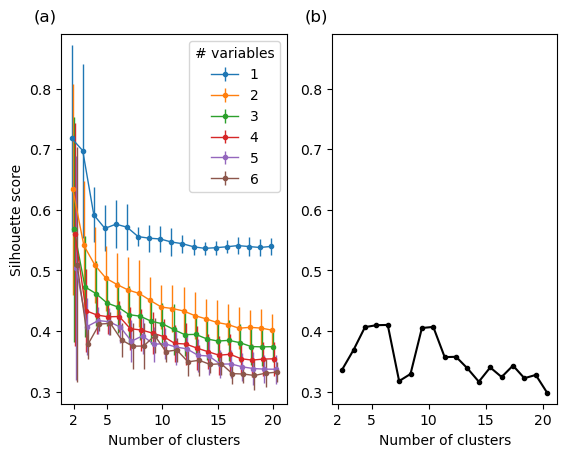

In [9]:
fig, axs = plt.subplots(1,2)

for nvar in [1,2,3,4,5,6]:
    axs[0].errorbar(np.linspace(2,20,19)+0.1*(nvar-3),np.nanmean(silhouette_vec[:,nvar-1,:].squeeze(),axis=1),
                 yerr = np.nanstd(silhouette_vec[:,nvar-1,:].squeeze(),axis=1),linestyle='-',linewidth=1,marker='.',label=str(nvar))
axs[0].legend(title = '# variables')
axs[0].set_xticks([2,5,10,15,20])
axs[0].set_xlabel('Number of clusters')
axs[0].set_ylabel('Silhouette score')
axs[0].set_ylim((0.28,0.89))
axs[0].text(
0.0, 1.0, '(a)', transform=(
    axs[0].transAxes + ScaledTranslation(-20/72, +7/72, fig.dpi_scale_trans)),
fontsize=12, va='bottom')

nvar = 7
axs[1].errorbar(np.linspace(2,20,19)+0.1*(nvar-3),np.nanmean(silhouette_vec[:,nvar-1,:].squeeze(),axis=1),
                 yerr = np.nanstd(silhouette_vec[:,nvar-1,:].squeeze(),axis=1),linestyle='-',marker='.',label=str(nvar),color='black')
axs[1].set_xticks([2,5,10,15,20])
axs[1].set_xlabel('Number of clusters')
axs[1].set_ylim((0.28,0.89))
axs[0].text(
0.0, 1.0, '(b)', transform=(
    axs[1].transAxes + ScaledTranslation(-20/72, +7/72, fig.dpi_scale_trans)),
fontsize=12, va='bottom')
#plt.savefig('/users/modellers/rmi/Documents/FOCUS/kmeans_figures/silhouette_score.png')